<a href="https://colab.research.google.com/github/lovnishverma/iris-demo/blob/main/iris_India_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab Notebooks: https://github.com/lovnishverma/Python-Getting-Started

**Outliers:** https://blog.devgenius.io/a-beginners-guide-to-detecting-and-handling-outliers-with-pizza-coffee-examples-243c3a2f1785

https://github.com/lovnishverma/Python-Getting-Started/blob/main/Handling_Outliers.ipynb

**PPT:** https://github.com/lovnishverma/Slidespptspdfs/blob/main/Machine%20Learning/Intro%20to%20Machine%20Learning.pdf

In [63]:
import pandas as pd

In [64]:
df = pd.read_csv("https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv")

In [65]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [66]:
df['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [67]:
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()

df[['sepal_length',	'sepal_width',	'petal_length', 'petal_width']] = scalar.fit_transform(df[['sepal_length',	'sepal_width',	'petal_length', 'petal_width']])


df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,-0.900681,1.032057,-1.341272,-1.312977,setosa
1,-1.143017,-0.124958,-1.341272,-1.312977,setosa
2,-1.385353,0.337848,-1.398138,-1.312977,setosa
3,-1.506521,0.106445,-1.284407,-1.312977,setosa
4,-1.021849,1.263460,-1.341272,-1.312977,setosa
5,-0.537178,1.957669,-1.170675,-1.050031,setosa
6,-1.506521,0.800654,-1.341272,-1.181504,setosa
7,-1.021849,0.800654,-1.284407,-1.312977,setosa
8,-1.748856,-0.356361,-1.341272,-1.312977,setosa
9,-1.143017,0.106445,-1.284407,-1.444450,setosa


Understanding and Handling Imbalanced Datasets in Classification Models

https://blog.devgenius.io/understanding-and-handling-imbalanced-datasets-in-classification-models-bb10ac6fa1a7

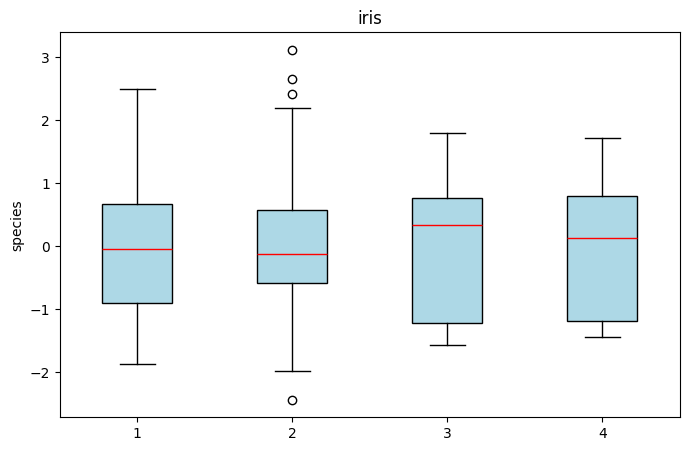

In [68]:
# box plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.boxplot(x=df[['sepal_length',	'sepal_width',	'petal_length', 'petal_width']], patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red'))
plt.title("iris")
plt.ylabel("species")
plt.show()


In [69]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-4.736952e-16,-6.631732e-16,3.315866e-16,-2.842171e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.438987e+00,-1.568735e+00,-1.444450e+00
25%,-9.006812e-01,-5.877635e-01,-1.227541e+00,-1.181504e+00
50%,-5.250608e-02,-1.249576e-01,3.362659e-01,1.332259e-01
75%,6.745011e-01,5.692513e-01,7.627586e-01,7.905908e-01
max,2.492019e+00,3.114684e+00,1.786341e+00,1.710902e+00


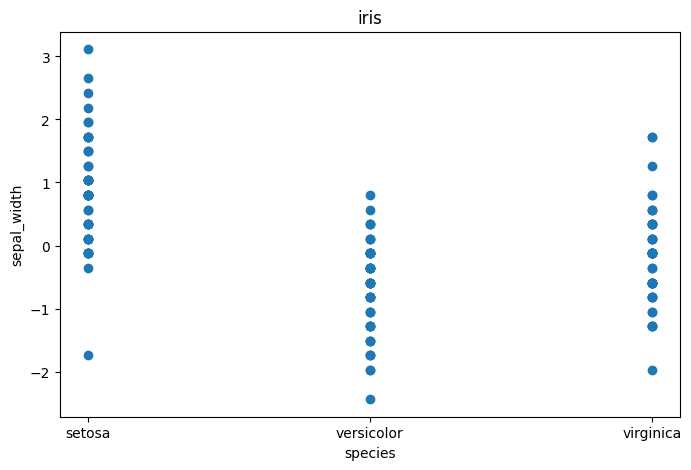

In [70]:
plt.figure(figsize=(8, 5))
plt.scatter(x=df['species'], y=df['sepal_width'])
plt.title("iris")
plt.ylabel("sepal_width")
plt.xlabel("species")
plt.show()


In [71]:
X = df[['sepal_length',	'sepal_width',	'petal_length', 'petal_width']] # features

y = df['species'] # Target

Class distribution in full dataset: Counter({'setosa': 50, 'versicolor': 50, 'virginica': 50})


/tmp/ipykernel_1693/351278052.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="Set2")


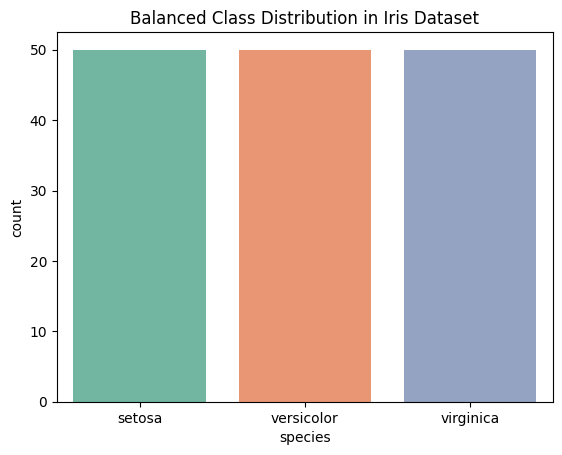

In [72]:
import seaborn as sns
from collections import Counter
print("Class distribution in full dataset:", Counter(y))
sns.countplot(x=y, palette="Set2")
plt.title("Balanced Class Distribution in Iris Dataset")
plt.show()

In [73]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977
...,...,...,...,...
145,1.038005,-0.124958,0.819624,1.447956
146,0.553333,-1.281972,0.705893,0.922064
147,0.795669,-0.124958,0.819624,1.053537
148,0.432165,0.800654,0.933356,1.447956


In [74]:
from sklearn.model_selection import train_test_split
from collections import Counter

# Without stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train distribution (no stratify):", Counter(y_train))
print("Train distribution (no stratify):", Counter(y_test))

Train distribution (no stratify): Counter({'versicolor': 41, 'setosa': 40, 'virginica': 39})
Train distribution (no stratify): Counter({'virginica': 11, 'setosa': 10, 'versicolor': 9})


In [75]:
from sklearn.model_selection import train_test_split
from collections import Counter

# Without stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train distribution (no stratify):", Counter(y_train))
print("Train distribution (no stratify):", Counter(y_test))

Train distribution (no stratify): Counter({'setosa': 40, 'virginica': 40, 'versicolor': 40})
Train distribution (no stratify): Counter({'setosa': 10, 'virginica': 10, 'versicolor': 10})


In [76]:
X_train.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,120.000000,120.000000,120.000000,120.000000
mean,-0.002019,-0.022755,0.006919,0.007231
std,1.018932,1.031292,1.005054,1.004223
min,-1.870024,-2.438987,-1.511870,-1.444450
25%,-0.900681,-0.587764,-1.227541,-1.181504
50%,-0.113090,-0.124958,0.279400,0.133226
75%,0.674501,0.569251,0.762759,0.790591
max,2.492019,3.114684,1.786341,1.710902


In [77]:
y_train.describe()

,species
count,120
unique,3
top,setosa
freq,40


In [78]:
X_test.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,30.000000,30.000000,30.000000,30.000000
mean,0.008078,0.091018,-0.027675,-0.028924
std,0.955005,0.892986,1.013109,1.016442
min,-1.748856,-1.744778,-1.568735,-1.312977
25%,-0.718929,-0.298510,-1.255974,-1.312977
50%,0.250414,-0.124958,0.421564,0.264699
75%,0.795669,0.569251,0.748542,0.790591
max,1.765012,2.189072,1.445147,1.579429


In [79]:
y_test.describe()

,species
count,30
unique,3
top,setosa
freq,10


In [80]:
from sklearn.linear_model import LogisticRegression

In [81]:
 model = LogisticRegression()


model.fit(X_train, y_train)

LogisticRegression()

In [82]:
X_test.head(3)

,sepal_length,sepal_width,petal_length,petal_width
38,-1.748856,-0.124958,-1.398138,-1.312977
127,0.310998,-0.124958,0.649027,0.790591
57,-1.143017,-1.513375,-0.260824,-0.261193


In [83]:
y_test.head()

,species
38,setosa
127,virginica
57,versicolor
93,versicolor
42,setosa


In [84]:
# Model evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9333333333333333


In [85]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



https://www.w3schools.com/python/python_ml_confusion_matrix.asp

In [86]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


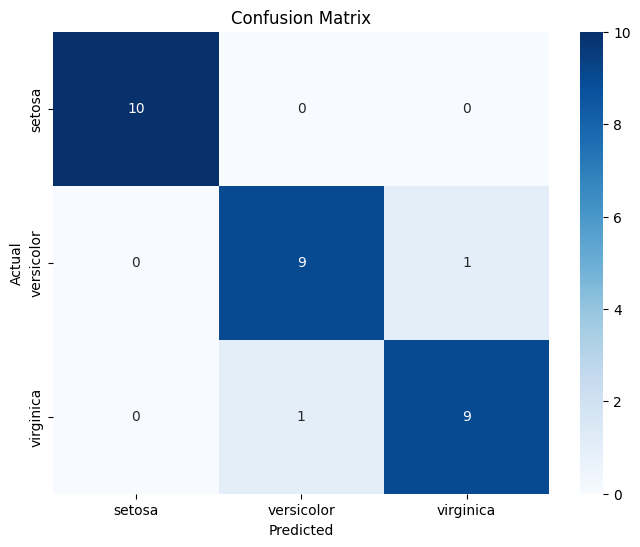

In [87]:
# confusion_matrix using matpotlib with proper labels and title

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix_plot.png")
plt.show()

In [88]:
# test on unseen input

prediction = model.predict([[6.7,3.5,5.3,2.5]])


print(prediction[0])

virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [89]:
# taking input from user

sepal_length = float(input("Enter sepal_length: "))
sepal_width = float(input("Enter sepal_width: "))
petal_length = float(input("Enter petal_length: "))
petal_width = float(input("Enter petal_width: "))

prediction = model.predict([[sepal_length, sepal_width, petal_length, petal_width]])

print(prediction[0])

Enter sepal_length: 6.5
Enter sepal_width: 3.4
Enter petal_length: 5.2
Enter petal_width: 2.4
virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [90]:
import joblib

# save model

joblib.dump(model, "model.joblib")

['model.joblib']

In [91]:
# save scalar

joblib.dump(scalar, "scaler.joblib")

['scaler.joblib']

In [92]:
# load model

loaded_model = joblib.load("model.joblib")

# load scalar
scaler = joblib.load("scaler.joblib")

In [100]:
features = [[6.7,3.5,5.3,2.5]]


# Scale the input
features_scaled = scaler.transform(features)

# Predict
prediction = loaded_model.predict(features_scaled)

print(f" The Predicted flower is: {prediction[0]}")

 The Predicted flower is: virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


What's Next: https://github.com/lovnishverma/iris-demo

Live Demo: https://iris-demo-gjle.onrender.com/